In [1]:
# Code block generated with Gemini; prompt "All seeds needed for reproducibility in pytorch based DL project"

import os
import random
import numpy as np
import torch

def set_all_seeds(seed_value=42):
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.enabled = True
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

set_all_seeds(42)

In [2]:
import cv2
from tqdm import tqdm
import numpy as np

def calculate_blur_score_fft(input_data, radius=30):
    if isinstance(input_data, str):
        img = cv2.imread(input_data, 0)
    else:
        if len(input_data.shape) == 3:
                # Handle float (0-1) vs uint8 (0-255)
                if input_data.dtype != np.uint8:
                    input_data = (input_data * 255).astype(np.uint8)
                img = cv2.cvtColor(input_data, cv2.COLOR_RGB2GRAY)
        else:
            img = input_data
    rows, cols = img.shape
    crow, ccol = rows // 2 , cols // 2
    dft = np.fft.fft2(img)
    dft_shift = np.fft.fftshift(dft) # this function helps shift all the zero freq points to centre
    magnitude_spectrum = np.abs(dft_shift)
    mask = np.zeros((rows, cols), np.uint8)
    cv2.circle(mask, (ccol, crow), radius, 1, -1)
    low_freq_area = magnitude_spectrum * mask
    high_freq_area = magnitude_spectrum * (1 - mask)
    low_energy = np.sum(low_freq_area)
    high_energy = np.sum(high_freq_area)
    ratio = high_energy / low_energy
    return ratio

root_dir = "/home/nam/projects/sid/Motion-Deblurring/gopro_deblur/blur/images"
image_and_blur_score = []

for file in tqdm(os.listdir(root_dir)):
    full_path = os.path.join(root_dir, file)
    blur_score = calculate_blur_score_fft(full_path).item()
    image_and_blur_score.append([full_path, round(blur_score, 3)])

# Sorting in descending order according to blur_score, so that we can then split this into buckets of low, medium and high
# A high ratio means the image is sharp
sorted_blur_scores = sorted(image_and_blur_score, key=lambda x: x[1], reverse=True)

100%|██████████| 1029/1029 [00:59<00:00, 17.27it/s]


In [3]:
low_idx = len(sorted_blur_scores)//3
mid_idx = (len(sorted_blur_scores)*2)//3
high_idx = len(sorted_blur_scores)

low_blur_bucket, mid_blur_bucket, high_blur_bucket = sorted_blur_scores[:low_idx], sorted_blur_scores[low_idx:mid_idx], sorted_blur_scores[mid_idx:high_idx]
print(len(low_blur_bucket), len(mid_blur_bucket), len(high_blur_bucket))

343 343 343


In [4]:
low_blur_sample = random.choice(low_blur_bucket)
mid_blur_sample = random.choice(mid_blur_bucket)
high_blur_sample = random.choice(high_blur_bucket)

### DETR Inference

- Code taken from Github homepage of DETR - colab hands on example. The below codeblock is NOT mine

Link to below code block: https://colab.research.google.com/github/facebookresearch/detr/blob/colab/notebooks/detr_attention.ipynb

In [5]:
import math

from PIL import Image
import requests
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

import ipywidgets as widgets
from IPython.display import display, clear_output

import torch
from torch import nn
from torchvision.models import resnet50
import torchvision.transforms as T
torch.set_grad_enabled(False)


# COCO classes
CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

# colors for visualization
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

# standard PyTorch mean-std input image normalization
transform = T.Compose([
    T.Resize(800),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

model = torch.hub.load('facebookresearch/detr', 'detr_resnet50', pretrained=True)
model.eval()

Using cache found in /home/nam/.cache/torch/hub/facebookresearch_detr_main
/home/nam/miniconda3/envs/diff/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nam/miniconda3/envs/diff/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DETR(
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (decoder): TransformerDecoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerDecoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, ou

In [6]:
# for output bounding box post-processing Code taken from the above link
def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)

def rescale_bboxes(out_bbox, size):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32)
    return b

def plot_results(pil_img, prob, boxes, plot_it=True):
    if plot_it:
        plt.figure(figsize=(10,4))
        plt.imshow(pil_img)
        ax = plt.gca()
    colors = COLORS * 100
    for p, (xmin, ymin, xmax, ymax), c in zip(prob, boxes.tolist(), colors):
        if plot_it:
            ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                    fill=False, color=c, linewidth=3))
            cl = p.argmax()
            text = f'{CLASSES[cl]}: {p[cl]:0.2f}'
            ax.text(xmin, ymin, text, fontsize=15,
                    bbox=dict(facecolor='yellow', alpha=0.5))
        else:
            cl = p.argmax()
            text = f'{CLASSES[cl]}: {p[cl]:0.2f}'
            print(text)
    if plot_it:
        plt.axis('off')
        plt.show()

### Inferring the DETR Model on the Blur vs its Sharp counterpart

- This is to get a visual understanding of how the model might behave differently

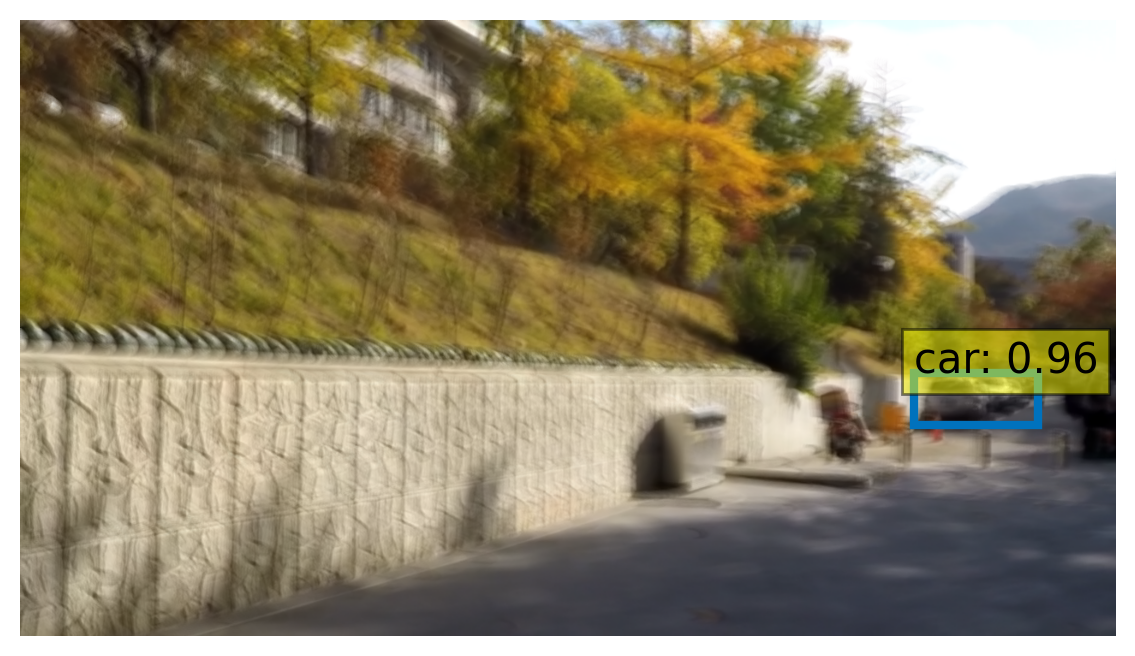

******************************************************************************************************************************************************


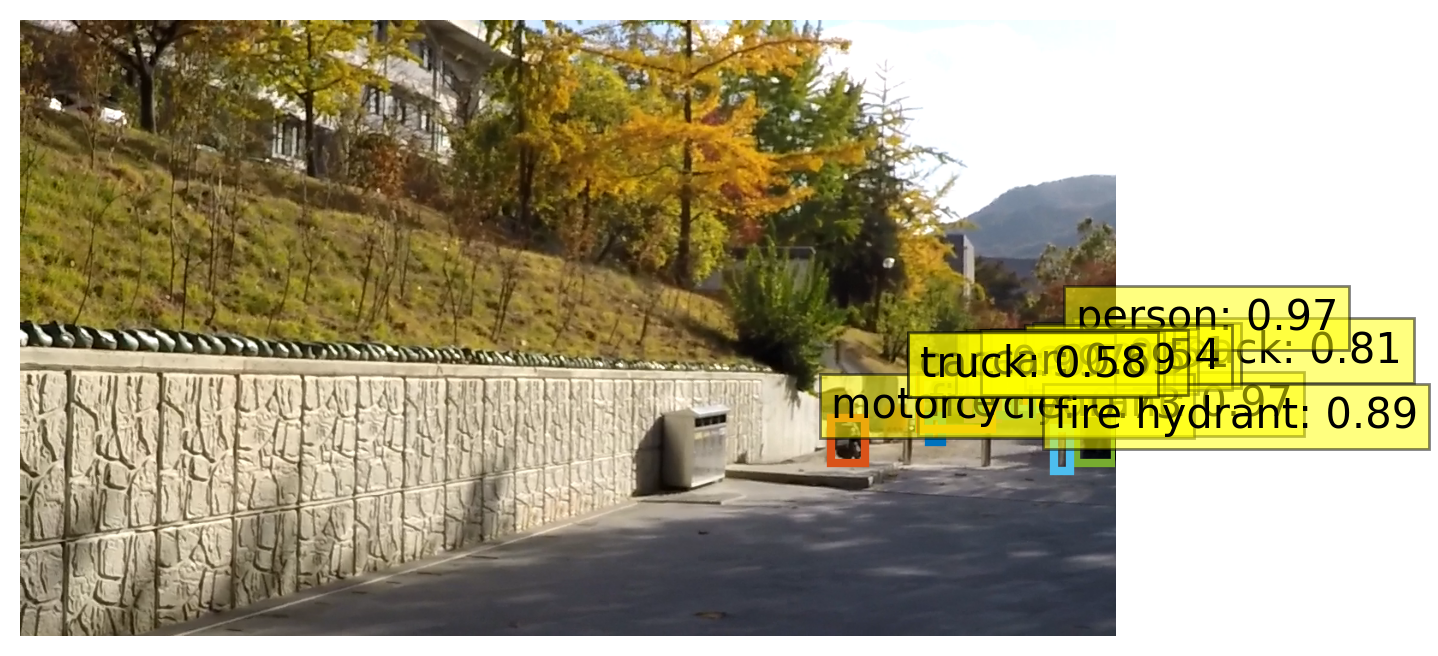

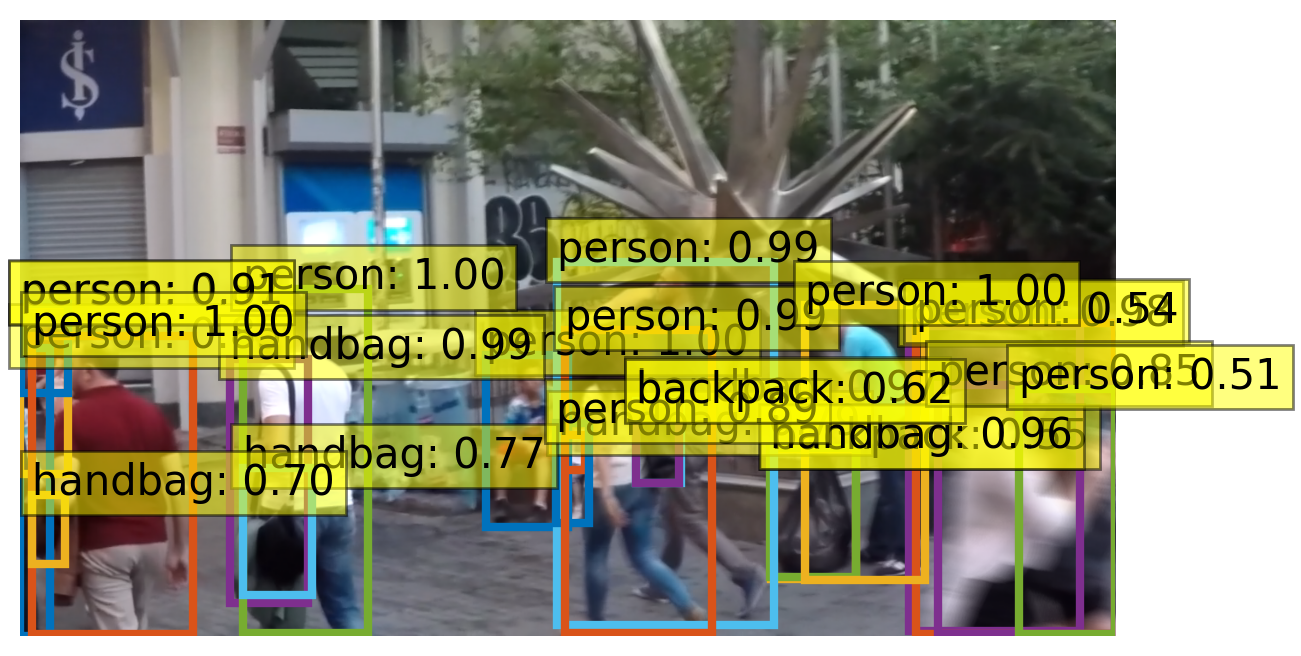

******************************************************************************************************************************************************


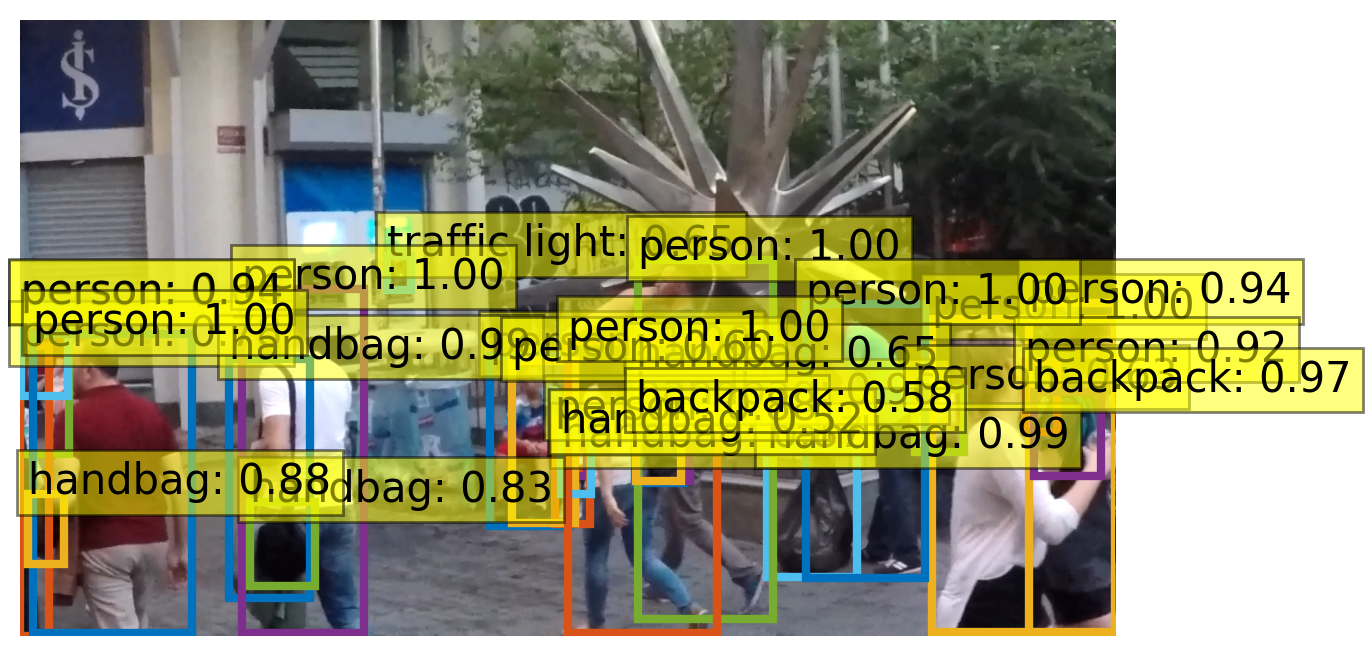

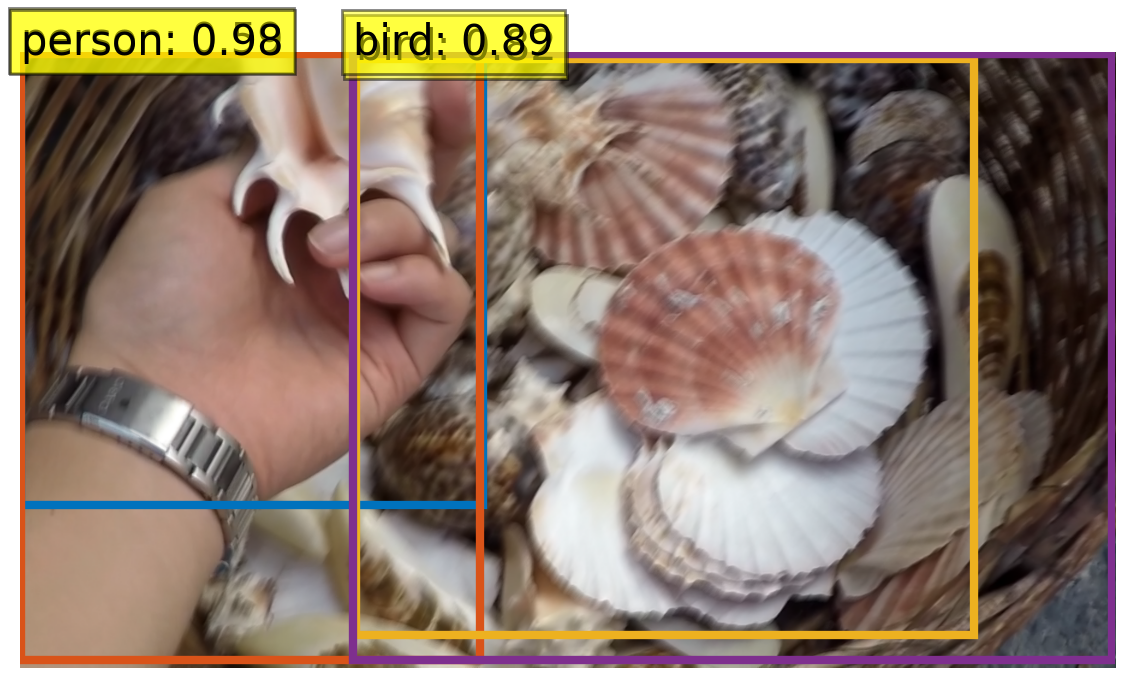

******************************************************************************************************************************************************


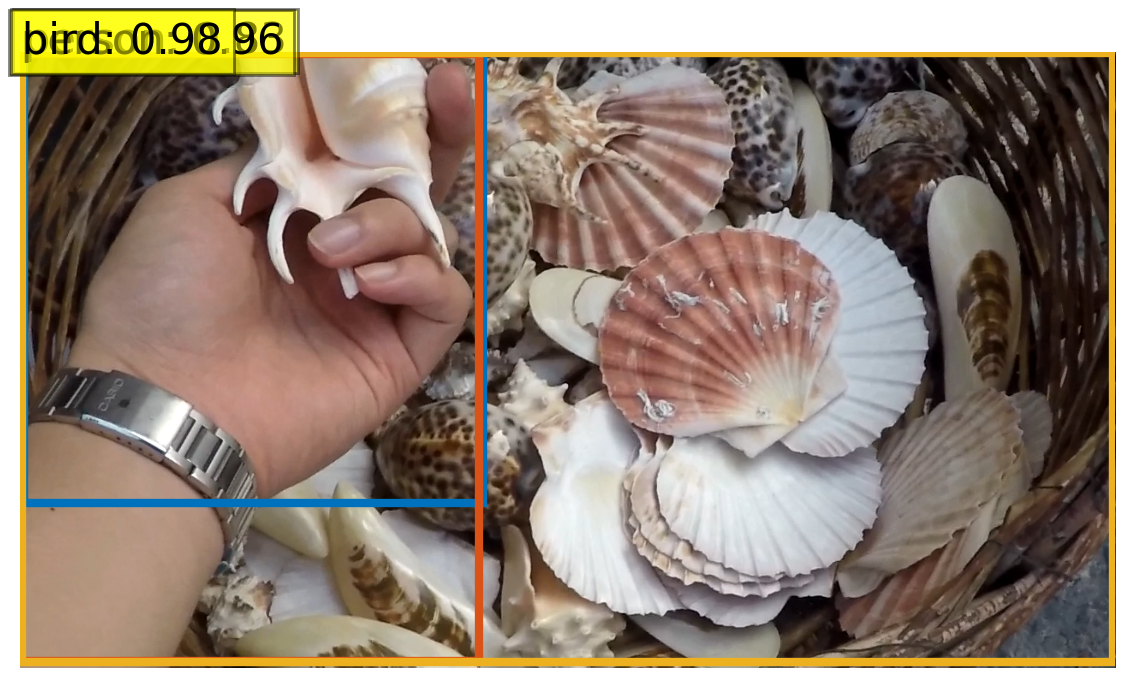

In [7]:
def infer_detr_and_plot_with_conf(image_path):
    im = Image.open(image_path)

    img = transform(im).unsqueeze(0)
    outputs = model(img)

    # keep only predictions with 0.5+ confidence
    probas = outputs['pred_logits'].softmax(-1)[0, :, :-1]
    keep = probas.max(-1).values > 0.5

    # convert boxes from [0; 1] to image scales
    bboxes_scaled = rescale_bboxes(outputs['pred_boxes'][0, keep], im.size)
    plot_results(im, probas[keep], bboxes_scaled)

infer_detr_and_plot_with_conf(low_blur_sample[0])
print("***"*50)
infer_detr_and_plot_with_conf(low_blur_sample[0].replace("/blur", "/sharp"))
print("==="*50)
infer_detr_and_plot_with_conf(mid_blur_sample[0])
print("***"*50)
infer_detr_and_plot_with_conf(mid_blur_sample[0].replace("/blur", "/sharp"))
print("==="*50)
infer_detr_and_plot_with_conf(high_blur_sample[0])
print("***"*50)
infer_detr_and_plot_with_conf(high_blur_sample[0].replace("/blur", "/sharp"))
print("==="*50)

In [8]:
#  AI used to generate these 2 helper functions for creating detection report of deblurred vs original, logged to genAI logs
"""Calculates Intersection over Union (IoU) between two boxes."""
def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

"""Helper to return raw probabilities and scaled boxes."""
def get_detr_outputs(image_path, threshold=0.5):
    im = Image.open(image_path)
    img = transform(im).unsqueeze(0)
    outputs = model(img)
    
    probas = outputs['pred_logits'].softmax(-1)[0, :, :-1]
    keep = probas.max(-1).values > threshold
    
    boxes = rescale_bboxes(outputs['pred_boxes'][0, keep], im.size)
    probs = probas[keep]
    
    return probs, boxes

def calculate_ap(precisions, recalls):
    """Calculates the Area Under the Curve using the 11-point interpolation or all-points."""
    # Append sentinel values to boundaries
    mpre = np.concatenate(([0.], precisions, [0.]))
    mrec = np.concatenate(([0.], recalls, [1.]))

    # Compute the precision envelope
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])

    # Integrate area under curve
    indices = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[indices + 1] - mrec[indices]) * mpre[indices + 1])
    return ap

In [9]:
import pandas as pd

def benchmark_detection(gt_data, test_data, iou_thresh=0.5):
    """
    gt_data: (probs, boxes) from Sharp image
    test_data: (probs, boxes) from Blur or Deblur image
    """
    gt_probs, gt_boxes = gt_data
    t_probs, t_boxes = test_data
    
    tp = 0
    fp = 0
    fn = 0
    confidences = []
    
    matched_test_indices = set()
    
    for i, g_box in enumerate(gt_boxes):
        g_cls = gt_probs[i].argmax().item()
        
        best_iou = 0
        match_idx = -1
        
        for j, t_box in enumerate(t_boxes):
            if j in matched_test_indices: continue
            
            iou = calculate_iou(g_box.tolist(), t_box.tolist())
            t_cls = t_probs[j].argmax().item()
            
            if iou > best_iou and t_cls == g_cls:
                best_iou = iou
                match_idx = j
        
        if best_iou >= iou_thresh:
            tp += 1
            matched_test_indices.add(match_idx)
            confidences.append(t_probs[match_idx].max().item())
        else:
            fn += 1
            
    # 2. Calculate FPs (Detections in test that aren't in GT)
    fp = len(t_boxes) - len(matched_test_indices)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {"precision": precision, "recall": recall, "f1": f1, "tp": tp, "fp": fp, "fn": fn}


def run_full_benchmark(bucket, label):
    blur_stats = []
    deblur_stats = []
    
    # Process a representative sample from the bucket (e.g., 50 images)
    for img_path, _ in tqdm(bucket, desc=f"Benchmarking {label}"):
        sharp_path = img_path.replace("/blur", "/sharp")
        deblur_path = img_path.replace("/blur/images", "/deblur_richardson_filter")
        
        # 1. Generate "Ground Truth" from Sharp image
        gt_data = get_detr_outputs(sharp_path)
        if len(gt_data[1]) == 0: continue # Skip if no objects in sharp image
        
        # 2. Get test detections
        blur_out = get_detr_outputs(img_path)
        deblur_out = get_detr_outputs(deblur_path)
        
        # 3. Benchmark
        blur_stats.append(benchmark_detection(gt_data, blur_out))
        deblur_stats.append(benchmark_detection(gt_data, deblur_out))
        
    # Aggregate results into a DataFrame
    df_blur = pd.DataFrame(blur_stats).mean().to_frame().T
    df_blur['condition'] = 'Blurred'
    df_blur['severity'] = label
    
    df_deblur = pd.DataFrame(deblur_stats).mean().to_frame().T
    df_deblur['condition'] = 'Restored'
    df_deblur['severity'] = label
    
    return pd.concat([df_blur, df_deblur])

# Run for all buckets
results = []
for bucket, label in [(low_blur_bucket, 'Low'), (mid_blur_bucket, 'Mid'), (high_blur_bucket, 'High')]:
    results.append(run_full_benchmark(bucket, label))

final_report = pd.concat(results).set_index(['severity', 'condition'])
display(final_report)

import seaborn as sns

plt.figure(figsize=(10, 6))
plot_df = final_report.reset_index()
sns.barplot(data=plot_df, x='severity', y='f1', hue='condition', palette='viridis')
plt.title("Object Detection Robustness: Blur vs. Restoration")
plt.ylabel("F1-Score (Compared to Sharp GT)")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Benchmarking Low:   0%|          | 0/343 [00:00<?, ?it/s]

Benchmarking Mid:  13%|█▎        | 46/343 [02:23<15:27,  3.12s/it]


KeyboardInterrupt: 

In [ ]:
def collect_global_detections(bucket, mode='blur', iou_thresh=0.5):
    """
    mode: 'blur' or 'deblur'
    Returns: A list of dicts with [confidence, is_tp]
    """
    all_detections = []
    total_gt_count = 0

    for img_path, _ in tqdm(bucket, desc=f"Collecting {mode} detections"):
        sharp_path = img_path.replace("/blur", "/sharp")
        if mode == 'blur':
            test_path = img_path
        else:
            test_path = img_path.replace("/blur/images", "/deblur_richardson_filter")

        # 1. Get GT (Sharp) and Test detections
        # Note: Set threshold to 0.0 here to get ALL boxes for a full PR curve
        gt_probs, gt_boxes = get_detr_outputs(sharp_path, threshold=0.3)
        t_probs, t_boxes = get_detr_outputs(test_path, threshold=0.0) 
        
        total_gt_count += len(gt_boxes)
        matched_gt_indices = set()

        # Sort test detections by confidence for this image
        if len(t_boxes) > 0:
            t_confs = t_probs.max(-1).values
            t_clss = t_probs.argmax(-1)
            
            # Sort indices by confidence descending
            indices = torch.argsort(t_confs, descending=True)
            
            for idx in indices:
                t_box = t_boxes[idx]
                t_conf = t_confs[idx].item()
                t_cls = t_clss[idx].item()
                
                best_iou = 0
                match_idx = -1
                
                for i, g_box in enumerate(gt_boxes):
                    if i in matched_gt_indices: continue
                    g_cls = gt_probs[i].argmax().item()
                    
                    if g_cls == t_cls:
                        iou = calculate_iou(g_box.tolist(), t_box.tolist())
                        if iou > best_iou:
                            best_iou = iou
                            match_idx = i
                
                if best_iou >= iou_thresh:
                    all_detections.append({'conf': t_conf, 'tp': 1})
                    matched_gt_indices.add(match_idx)
                else:
                    all_detections.append({'conf': t_conf, 'tp': 0})
                    
    return all_detections, total_gt_count

def compute_map(detections, total_gt):
    if not detections: return 0.0
    
    # Sort all detections across all images by confidence
    df = pd.DataFrame(detections).sort_values('conf', ascending=False)
    
    tp_cumsum = df['tp'].cumsum().values
    fp_cumsum = (1 - df['tp']).cumsum().values
    
    recalls = tp_cumsum / total_gt if total_gt > 0 else np.zeros_like(tp_cumsum)
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum)
    
    # Use the area under curve function you already have
    return calculate_ap(precisions, recalls), precisions, recalls

summary_data = []

for bucket, label in [(low_blur_bucket, 'Low'), (mid_blur_bucket, 'Mid'), (high_blur_bucket, 'High')]:
    # Compute for Blurred
    b_dets, b_gt = collect_global_detections(bucket, mode='blur')
    b_ap, b_p, b_r = compute_map(b_dets, b_gt)
    
    # Compute for Restored
    r_dets, r_gt = collect_global_detections(bucket, mode='deblur')
    r_ap, r_p, r_r = compute_map(r_dets, r_gt)
    
    summary_data.append({
        'Severity': label,
        'Blur mAP': round(b_ap, 4),
        'Restored mAP': round(r_ap, 4),
        'Delta': round(r_ap - b_ap, 4)
    })
    
    # Optional: Plot the curves for the high blur case
    if label == 'High':
        plt.figure(figsize=(8, 6))
        plt.plot(b_r, b_p, label=f'Blurred (mAP: {b_ap:.3f})')
        plt.plot(r_r, r_p, label=f'Restored (mAP: {r_ap:.3f})')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall Curve (High Severity)')
        plt.legend()
        plt.show()

print(pd.DataFrame(summary_data))

NameError: name 'low_blur_bucket' is not defined